In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import * 
from extrap import VarProLinearized
from functions import CBSFitPlotter
import re
pd.set_option('display.precision', 18)
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=18)

In [3]:
# def upload_df1(file_path):
#   df = pd.read_csv(file_path)
#   df['basis size'] = df['basis size'].astype(int)

#   return df[2:]

In [5]:
mu_16O_4_1De = upload_df('../muon/out_mu_16O+4_1De-01.csv')
mu_16O_4_1De = mu_16O_4_1De.rename(columns={'Basis Size': 'basis size'})
mu_16O_4_1De = mu_16O_4_1De.dropna(axis=1)

mu_16O_4_1Po = upload_df('../muon/out_mu_16O+4_1Po-01.csv')
mu_16O_4_1Po = mu_16O_4_1Po.rename(columns={'Basis Size': 'basis size'})
mu_16O_4_1Po = mu_16O_4_1Po.dropna(axis=1)

mu_16O_4_1Se = upload_df('../muon/out_mu_16O+4_1Se-01.csv')
mu_16O_4_1Se = mu_16O_4_1Se.rename(columns={'Basis Size': 'basis size'})
mu_16O_4_1Se = mu_16O_4_1Se.dropna(axis=1)

mu_16O_5_2De = upload_df('../muon/out_mu_16O+5_2De-01.csv')
mu_16O_5_2De = mu_16O_5_2De.rename(columns={'Basis Size': 'basis size'})
mu_16O_5_2De = mu_16O_5_2De.dropna(axis=1)

mu_16O_5_2Po = upload_df('../muon/out_mu_16O+5_2Po-01.csv')
mu_16O_5_2Po = mu_16O_5_2Po.rename(columns={'Basis Size': 'basis size'})
mu_16O_5_2Po = mu_16O_5_2Po.dropna(axis=1)

mu_16O_5_2Se = upload_df('../muon/out_mu_16O+5_2Se-01.csv')
mu_16O_5_2Se = mu_16O_5_2Se.rename(columns={'Basis Size': 'basis size'})
mu_16O_5_2Se = mu_16O_5_2Se.dropna(axis=1)

mu_16O_6_1De = upload_df('../muon/out_mu_16O+6_1De-01.csv')
mu_16O_6_1De = mu_16O_6_1De.rename(columns={'Basis Size': 'basis size'})
mu_16O_6_1De = mu_16O_6_1De.dropna(axis=1)

mu_16O_6_1Po = upload_df('../muon/out_mu_16O+6_1Po-01.csv')
mu_16O_6_1Po = mu_16O_6_1Po.rename(columns={'Basis Size': 'basis size'})
mu_16O_6_1Po = mu_16O_6_1Po.dropna(axis=1)

mu_16O_6_1Se = upload_df('../muon/out_mu_16O+6_1Se-01.csv')
mu_16O_6_1Se = mu_16O_6_1Se.rename(columns={'Basis Size': 'basis size'})
mu_16O_6_1Se = mu_16O_6_1Se.dropna(axis=1)

mu_16O_7_2De = upload_df('../muon/out_mu_16O+7_2De-01.csv')
mu_16O_7_2De = mu_16O_7_2De.rename(columns={'Basis Size': 'basis size'})
mu_16O_7_2De = mu_16O_7_2De.dropna(axis=1)

mu_16O_7_2Po = upload_df('../muon/out_mu_16O+7_2Po-01.csv')
mu_16O_7_2Po = mu_16O_7_2Po.rename(columns={'Basis Size': 'basis size'})
mu_16O_7_2Po = mu_16O_7_2Po.dropna(axis=1)

mu_16O_7_2Se = upload_df('../muon/out_mu_16O+7_2Se-01.csv')
mu_16O_7_2Se = mu_16O_7_2Se.rename(columns={'Basis Size': 'basis size'})
mu_16O_7_2Se = mu_16O_7_2Se.dropna(axis=1)

mu_infO_4_1De = upload_df('../muon/out_mu_infO+4_1De-01.csv')
mu_infO_4_1De = mu_infO_4_1De.rename(columns={'Basis Size': 'basis size'})
mu_infO_4_1De = mu_infO_4_1De.dropna(axis=1)

mu_infO_4_1Po = upload_df('../muon/out_mu_infO+4_1Po-01.csv')
mu_infO_4_1Po = mu_infO_4_1Po.rename(columns={'Basis Size': 'basis size'})
mu_infO_4_1Po = mu_infO_4_1Po.dropna(axis=1)

mu_infO_4_1Se = upload_df('../muon/out_mu_infO+4_1Se-01.csv')
mu_infO_4_1Se = mu_infO_4_1Se.rename(columns={'Basis Size': 'basis size'})
mu_infO_4_1Se = mu_infO_4_1Se.dropna(axis=1)

mu_infO_5_2De = upload_df('../muon/out_mu_infO+5_2De-01.csv')
mu_infO_5_2De = mu_infO_5_2De.rename(columns={'Basis Size': 'basis size'})
mu_infO_5_2De = mu_infO_5_2De.dropna(axis=1)

mu_infO_5_2Po = upload_df('../muon/out_mu_infO+5_2Po-01.csv')
mu_infO_5_2Po = mu_infO_5_2Po.rename(columns={'Basis Size': 'basis size'})
mu_infO_5_2Po = mu_infO_5_2Po.dropna(axis=1)

mu_infO_5_2Se = upload_df('../muon/out_mu_infO+5_2Se-01.csv')
mu_infO_5_2Se = mu_infO_5_2Se.rename(columns={'Basis Size': 'basis size'})
mu_infO_5_2Se = mu_infO_5_2Se.dropna(axis=1)

In [ ]:
be_1de = upload_df('../large-dataset/be_1De.xls')
be_1de = be_1de.drop(columns=['SO1', 'SO2'])
be_1de = be_1de.rename(columns={'Basis Size': 'basis size'})
be_1de_inf = be_1de.loc[be_1de['basis size'] == max(be_1de['basis size'])]
be_1de_init = be_1de.iloc[:-1]
be_1de_err = pd.read_csv('../large-dataset-err/be_1De_err.xls')
be_1de_err = be_1de_err.drop(columns=['SO1', 'SO2'])

be_3de = upload_df('../large-dataset/be_3De.xls')
be_3de = be_3de.rename(columns={'Basis Size': 'basis size'})
be_3de_inf = be_3de.loc[be_3de['basis size'] == max(be_3de['basis size'])]
be_3de_init = be_3de.iloc[:-1]
be_3de_err = pd.read_csv('../large-dataset-err/be_3De_err.xls')

be_3pe = upload_df('../large-dataset/be_3Pe.xls')
be_3pe = be_3pe.rename(columns={'Basis Size': 'basis size'})
be_3pe_inf = be_3pe.loc[be_3pe['basis size'] == max(be_3pe['basis size'])]
be_3pe_init = be_3pe.iloc[:-1]
be_3pe_err = pd.read_csv('../large-dataset-err/be_3Pe_err.xls')

li_2se = upload_df('../large-dataset/Li_2Se.csv')
li_2se = li_2se.drop(columns = ['SO1', 'SO2'])
li_2se = li_2se.rename(columns= {'Basis Size': 'basis size'})
li_2se_inf = li_2se.loc[li_2se['basis size'] == max(li_2se['basis size'])]
li_2se_init = li_2se.iloc[:-1]
li_2se_err = pd.read_csv('../large-dataset-err/li_2se_err.csv')

be_1se = upload_df('../large-dataset/Be_1Se.csv')
be_1se = be_1se.drop(columns = ['SO1', 'SO2'])
be_1se = be_1se.rename(columns= {'Basis Size': 'basis size'})
be_1se_inf = be_1se.loc[be_1se['basis size'] == max(be_1se['basis size'])]
be_1se_init = be_1se.iloc[:-1]
be_1se_err = pd.read_csv('../large-dataset-err/be_1se_err.csv')

be_3po = upload_df('../large-dataset/Be_3Po.csv')
be_3po = be_3po.drop(columns = ['SO1', 'SO2'])
be_3po = be_3po.rename(columns= {'Basis Size': 'basis size'})
be_3po_inf = be_3po.loc[be_3po['basis size'] == max(be_3po['basis size'])]
be_3po_init = be_3po.iloc[:-1]
be_3po_err = pd.read_csv('../large-dataset-err/be_3po_err.csv')

be_1po = upload_df('../large-dataset/Be_1Po.csv')
be_1po = be_1po.drop(columns = ['SO1', 'SO2'])
be_1po = be_1po.rename(columns= {'Basis Size': 'basis size'})
be_1po_inf = be_1po.loc[be_1po['basis size'] == max(be_1po['basis size'])]
be_1po_init = be_1po.iloc[:-1]
be_1po_err = pd.read_csv('../large-dataset-err/be_1po_err.csv')

li_2po = upload_df('../large-dataset/Li_2Po.csv')
li_2po = li_2po.drop(columns = ['SO1', 'SO2'])
li_2po = li_2po.rename(columns= {'Basis Size': 'basis size'})
li_2po_inf = li_2po.loc[li_2po['basis size'] == max(li_2po['basis size'])]
li_2po_init = li_2po.iloc[:-1]
li_2po_err = pd.read_csv('../large-dataset-err/li_2po_err.csv')

be_3se = upload_df('../large-dataset/Be_3Se.csv')
be_3se = be_3se.drop(columns = ['SO1', 'SO2'])
be_3se = be_3se.rename(columns= {'Basis Size': 'basis size'})
be_3se_inf = be_3se.loc[be_3se['basis size'] == max(be_3se['basis size'])]
be_3se_init = be_3se.iloc[:-1]
be_3se_err = pd.read_csv('../large-dataset-err/be_3se_err.csv')

be_1se_1po = upload_df('../large-dataset/Be_1Se_1Po.xls')
be_1se_1po = be_1se_1po.rename(columns= {'Basis Size': 'basis size'})
be_1se_1po_inf = be_1se_1po.loc[be_1se_1po['basis size'] == max(be_1se_1po['basis size'])]
be_1se_1po_init = be_1se_1po[:-3]
be_1se_1po_err = pd.read_csv('../large-dataset-err/be_1se_1po_err.csv')

li_2se_2po = upload_df('../large-dataset/Li_2Se_2Po.xls')
li_2se_2po = li_2se_2po.rename(columns= {'Basis Size': 'basis size'})
li_2se_2po_inf = li_2se_2po.loc[li_2se_2po['basis size'] == max(li_2se_2po['basis size'])]
li_2se_2po_init = li_2se_2po[:-3]
li_2se_2po_err = pd.read_csv('../large-dataset-err/li_2se_2po_err.csv')

be_3po_small = upload_df('../new-dataset/be_3po_test.csv')
be_3po_small = be_3po_small.rename(columns= {'Basis Size': 'basis size'})
be_3po_small_init = be_3po_small[:-2]
be_3po_small_inf = be_3po_small.iloc[[-2]]
be_3po_small_err = be_3po_small.loc[be_3po_small['basis size'] == max(be_3po_small['basis size'])]


 this trend is: False
  [B free]
[exponential         ] B=    9.733837 (free)  C_scaled=-0.000000680573957  C=-14.408237125928517  A=    0.000283  R²(log)=0.920449  SSR=1.7194e+00
[sqrt_exponential    ] B=   11.970737 (free)  C_scaled=-0.000003204930947  C=-14.408237145850842  A=    0.007117  R²(log)=0.974499  SSR=1.3009e+00
[power_law           ] B=    2.653119 (free)  C_scaled=-0.000038204064634  C=-14.408237422065399  A=    0.000000  R²(log)=0.993847  SSR=1.1222e+00

Model                  | C (Asymptote)     | Uncertainty          | Diff from Reference
exponential            | -14.408237126     | 8.89e-07             | 1.63e-07
sqrt_exponential       | -14.408237146     | 3.36e-07             | 1.43e-07
power_law              | -14.408237422     | 9.05e-08             | 1.34e-07


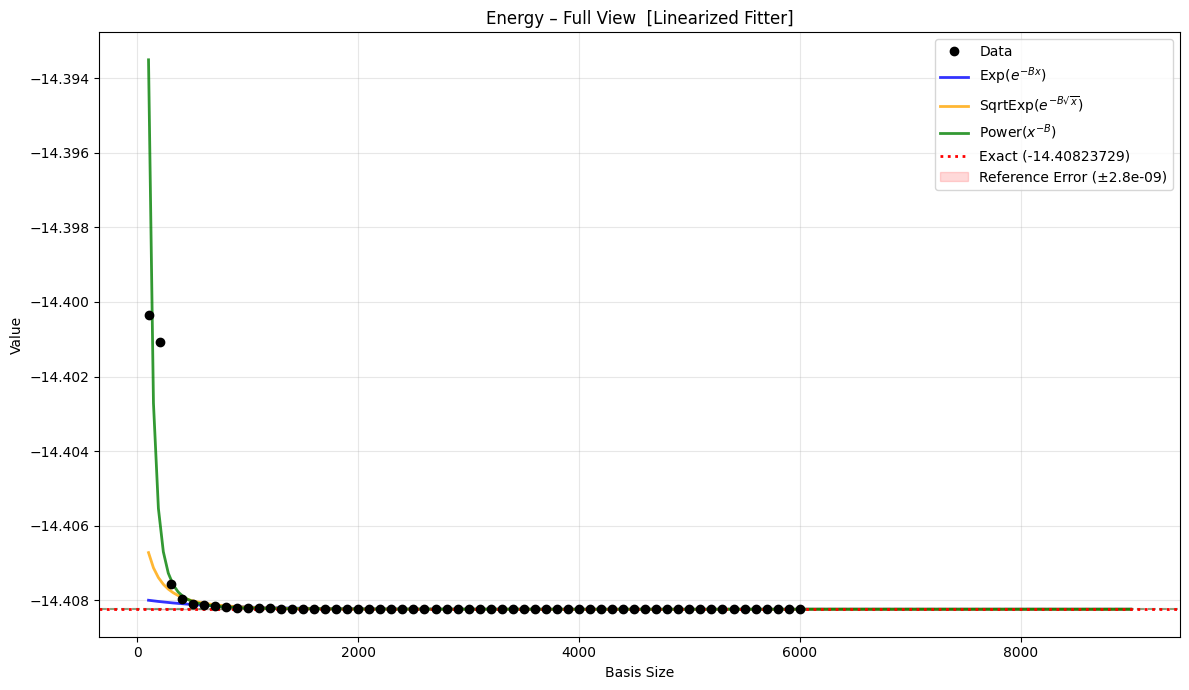

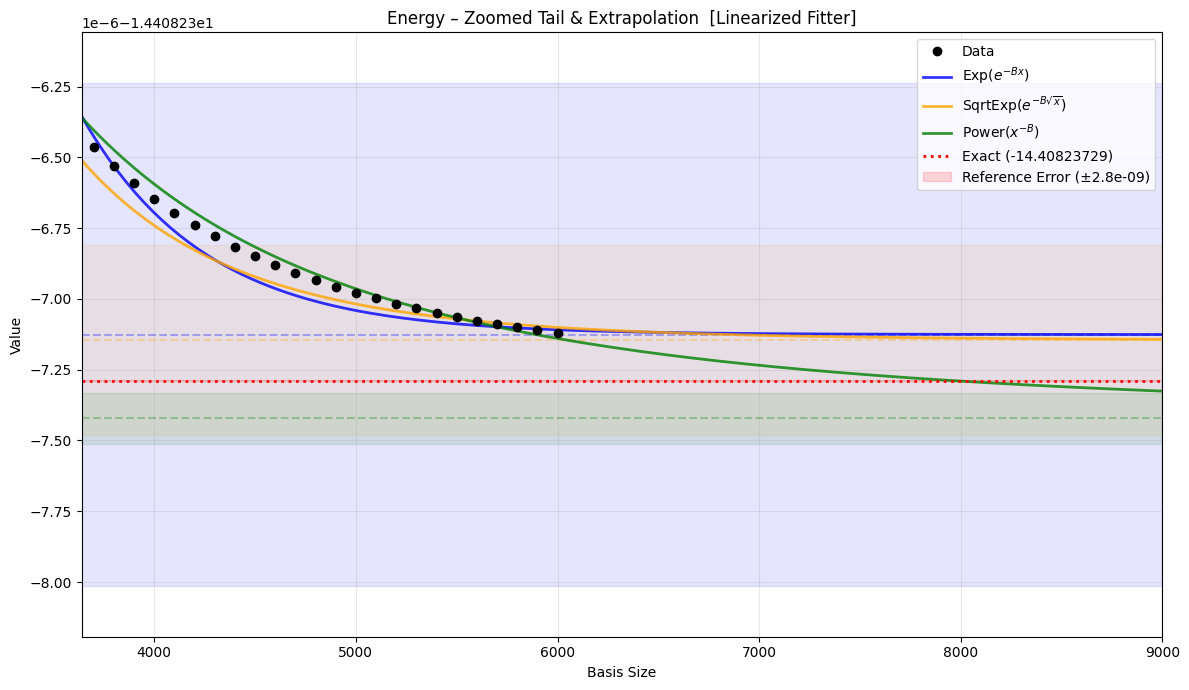

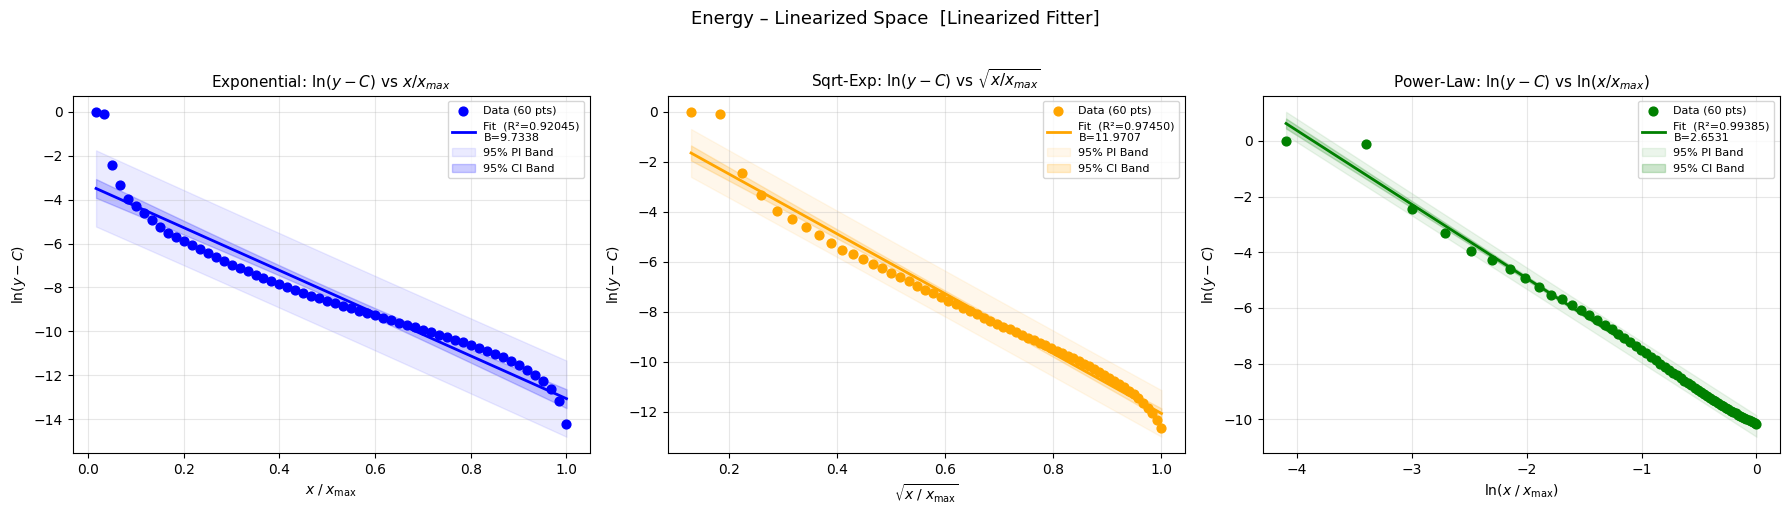

In [31]:
%matplotlib inline

solver = VarProLinearized(be_1de_init, 'basis size', 'Energy', inf_df = be_1de_inf, err_df=be_1de_err, use_energy_b=False)
solver.fit_linearized(verbose=True)
solver.plot()
solver.plot_log()
plt.show()


Fitting 18 columns for be_1de_init...
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False


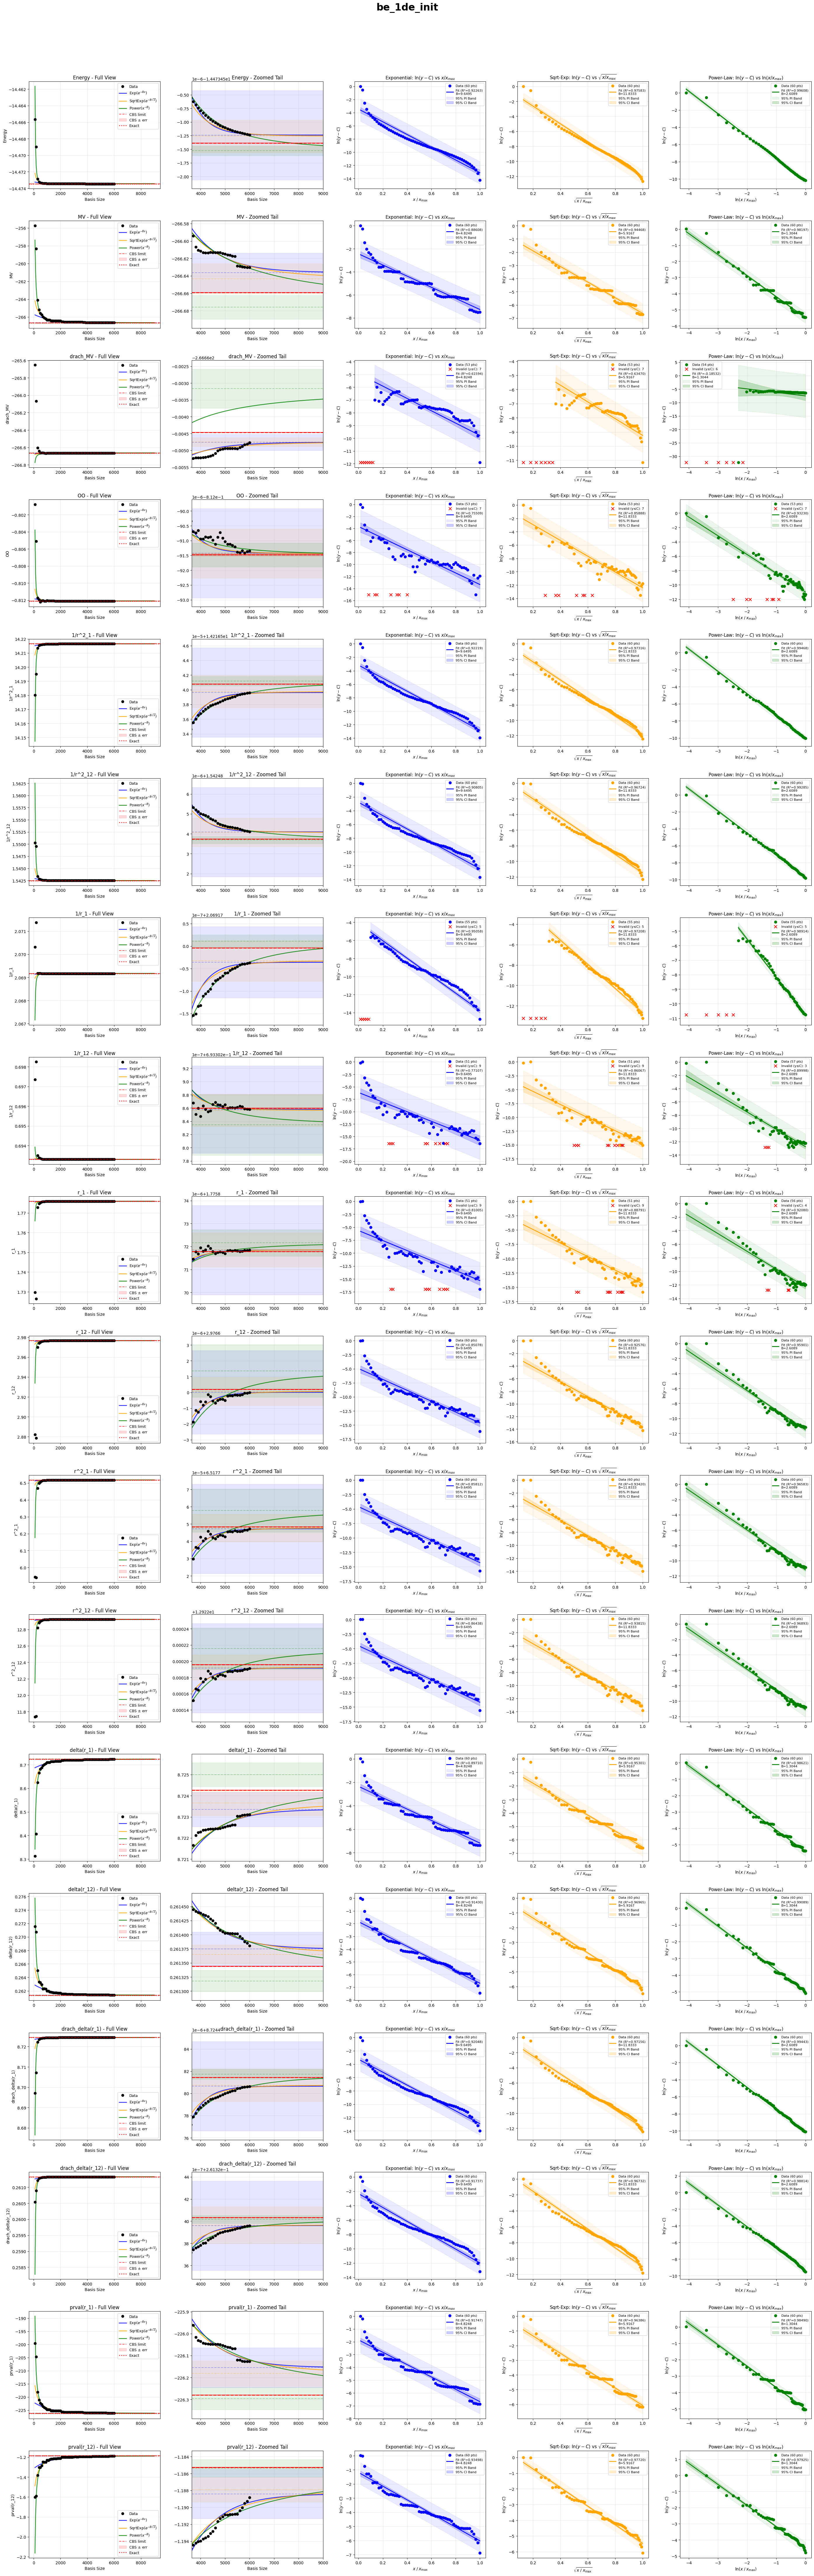

In [28]:
# Assuming you have a dataframe `df_be_1de` and an error dataframe `err_be_1de`
fit_and_plot_system(
    df=be_1po_init, 
    system_name='be_1de_init', 
    x_col='basis size', 
    err_df=be_1po_err, 
    inf_df=be_1po_inf,
    save_pdf=False
)

In [ ]:
CBSFitPlotter({
    'mu_16O_4_1De': mu_16O_4_1De,
    'mu_16O_4_1Po': mu_16O_4_1Po
}).run(save_pdf='all_muon_systems.pdf')

Fitting 31 columns for $\mu\,{}^{16}\mathrm{O}^{4+}\,{}^{1}D^{e}$...
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: True
 this trend is: False
 this trend is: False
 this trend is: False
 this trend is: True
 this trend is: Fal

'all_muon_systems.pdf'